## Validação Estatístico do BeamNG como Digital Twin (Circuito 1)

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import ast

In [43]:
# Carregar os dados do arquivo CSV
real = pd.read_csv('circuito1/real/2026-03-25 11-08-36 (2).csv')
simulado = pd.read_csv('circuito1/simulado/readable.csv', sep=';')

simulado['vel'] = simulado['vel'].apply(
        lambda x: np.sqrt(sum(i**2 for i in ast.literal_eval(x))) * 3.6
    )

real["time"] = pd.to_datetime(real["time"], format="%H:%M:%S.%f")

real["tempo_relativo"] = (real["time"] - real["time"].iloc[0]).dt.total_seconds()

simulado['tempo_relativo'] = simulado['time'] - simulado['time'].iloc[0]

In [44]:
colunas = {'tempo_relativo': 'tempo_relativo','vel': 'Velocidade (GPS) (km/h)', 'posY': 'Latitude', 'posX': 'Longtitude', 'posZ': 'Altitude (GPS) (m)'}

In [45]:
from sklearn.preprocessing import MinMaxScaler

def normalize_series(df, cols):
    scaler = MinMaxScaler()
    df_copy = df.copy()
    df_copy[cols] = scaler.fit_transform(df_copy[cols])
    return df_copy

# colunas numéricas que você quer comparar
cols_real = list(colunas.values())
cols_sim = list(colunas.keys())

real_norm = normalize_series(real, cols_real)
sim_norm = normalize_series(simulado, cols_sim)

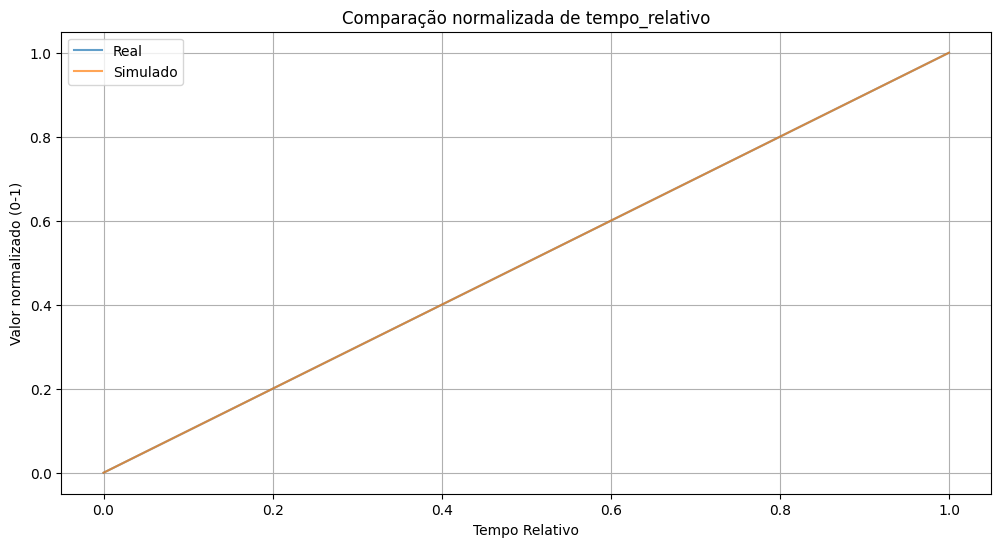

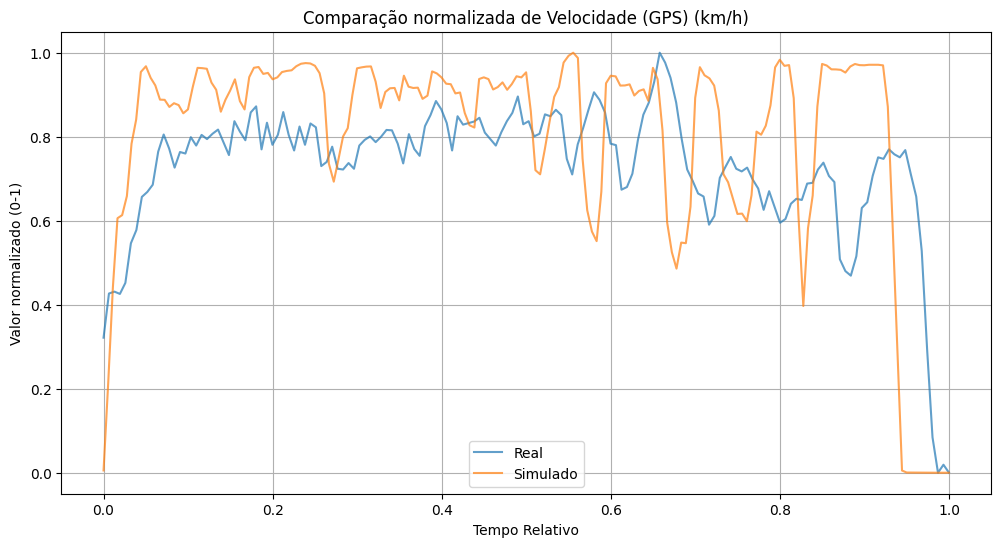

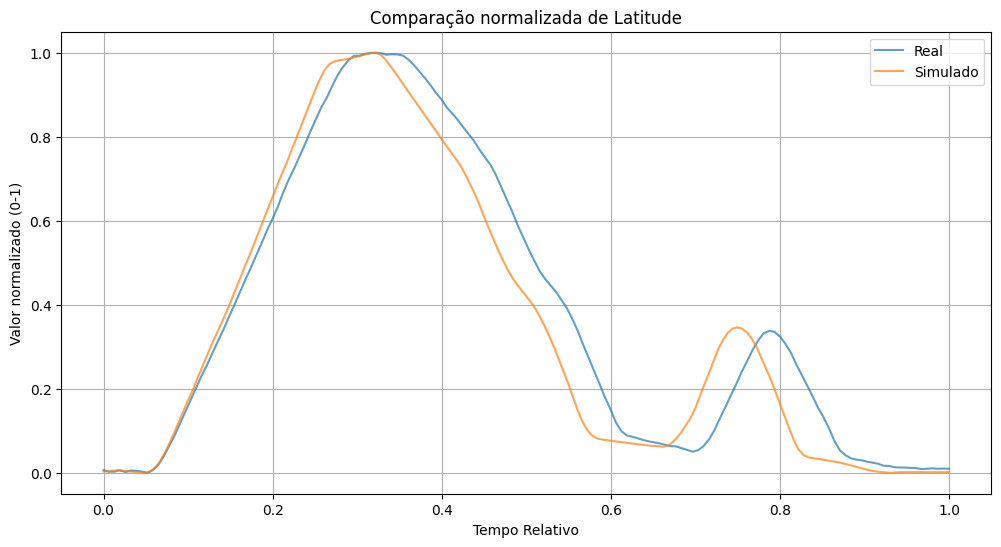

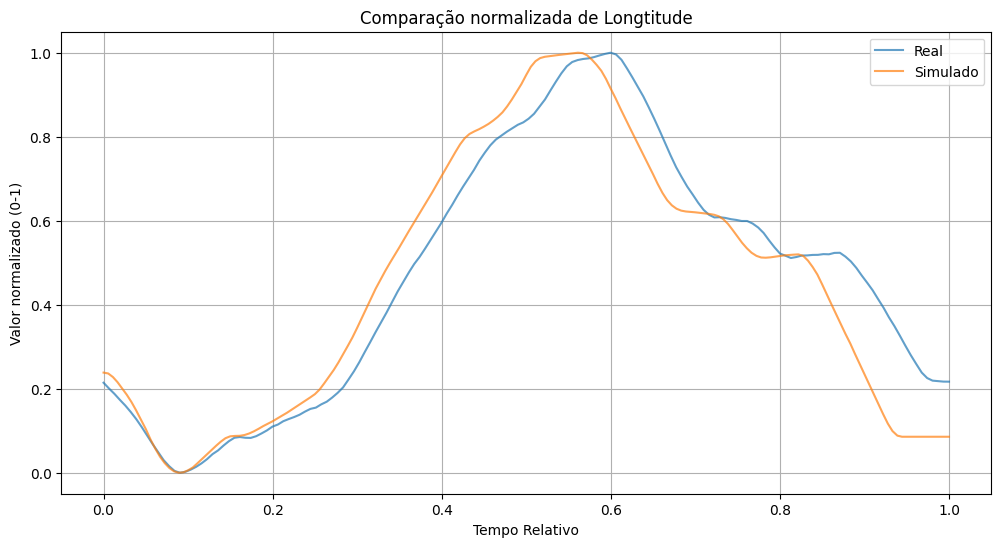

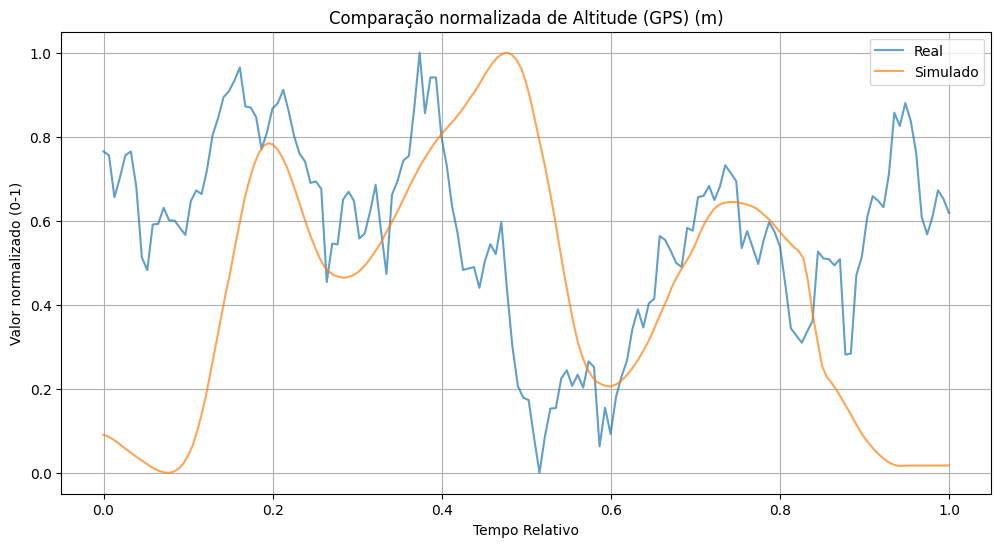

In [46]:
for c in colunas.keys():
    plt.figure(figsize=(12, 6))
    
    plt.plot(real_norm['tempo_relativo'], real_norm[colunas[c]],
             label='Real', alpha=0.7)
    
    plt.plot(sim_norm['tempo_relativo'], sim_norm[c],
             label='Simulado', alpha=0.7)

    plt.title(f'Comparação normalizada de {colunas[c]}')
    plt.xlabel('Tempo Relativo')
    plt.ylabel('Valor normalizado (0-1)')
    plt.legend()
    plt.grid()
    plt.show()

### Análise estatística

In [47]:
import numpy as np
import pandas as pd
from scipy import stats

# ----------------------------
# Ajuste de nomes (corrige CSV)
# ----------------------------
real = real.rename(columns={"Longtitude": "Longitude"})

# ----------------------------
# Mapeamento real vs simulado
# ----------------------------
pairs = {
    "Velocidade": ('Velocidade (GPS) (km/h)', 'vel'),
    "Latitude": ('Latitude', 'posY'),
    "Longitude": ('Longitude', 'posX'),
    "Altitude": ('Altitude (GPS) (m)', 'posZ')
}

# ----------------------------
# Função de alinhamento simples
# ----------------------------
def align(real_df, sim_df, rcol, scol):
    n = min(len(real_df), len(sim_df))
    return (
        real_df[rcol].values[:n],
        sim_df[scol].values[:n]
    )

# ----------------------------
# Estatísticas
# ----------------------------
def stats_all(x, y, name):
    x = np.array(x)
    y = np.array(y)

    print("\n" + "="*50)
    print(f"{name}")
    print("="*50)

    # -------- Teste t --------
    t_stat, t_p = stats.ttest_ind(x, y, equal_var=False)
    print(f"\n[Teste t]")
    print(f"t = {t_stat:.4f} | p = {t_p:.6f}")

    # -------- Pearson --------
    r, p_r = stats.pearsonr(x, y)
    print(f"\n[Pearson]")
    print(f"r = {r:.4f} | p = {p_r:.6f}")

    # -------- TOST --------
    delta = 0.1 * np.std(x - y)
    diff = x - y

    t1, p1 = stats.ttest_1samp(diff, -delta)
    t2, p2 = stats.ttest_1samp(diff, delta)

    print(f"\n[TOST]")
    print(f"delta = ±{delta:.4f}")
    print(f"p1 = {p1:.6f} | p2 = {p2:.6f}")

    if (p1 < 0.05 and p2 < 0.05):
        print("✔ Equivalente (TOST aprovado)")
    else:
        print("✖ Não equivalente")

# ----------------------------
# Execução geral
# ----------------------------
for name, (rcol, scol) in pairs.items():
    x, y = align(real, simulado, rcol, scol)
    stats_all(x, y, name)


Velocidade

[Teste t]
t = -7.4565 | p = 0.000000

[Pearson]
r = 0.4318 | p = 0.000000

[TOST]
delta = ±0.6836
p1 = 0.000000 | p2 = 0.000000
✔ Equivalente (TOST aprovado)

Latitude

[Teste t]
t = -41.4462 | p = 0.000000

[Pearson]
r = 0.9279 | p = 0.000000

[TOST]
delta = ±12.4552
p1 = 0.000000 | p2 = 0.000000
✔ Equivalente (TOST aprovado)

Longitude

[Teste t]
t = -23.4569 | p = 0.000000

[Pearson]
r = 0.9365 | p = 0.000000

[TOST]
delta = ±14.5889
p1 = 0.000000 | p2 = 0.000000
✔ Equivalente (TOST aprovado)

Altitude

[Teste t]
t = -32.9651 | p = 0.000000

[Pearson]
r = -0.4747 | p = 0.000000

[TOST]
delta = ±0.4070
p1 = 0.000000 | p2 = 0.000000
✔ Equivalente (TOST aprovado)
